In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

# print("Path to dataset files:", path)


In [5]:
import os
import librosa
import librosa.display
from librosa.feature import melspectrogram
import matplotlib.pyplot as plt
import numpy as np

In [23]:
class RAVDESSDataset:
    def __init__(self, base_path):
        self.base_path = base_path

    def load_audio(self, num_actors: int = 24):
        """
        load each audio (end with .wav) in each actor folder (start with Actor)
        save audio and audio data

        Args:
            num_actors (int, optional): The number of actors to load audio from. Defaults to 24.

        Returns:
            audio_files (list): A list of file paths for the loaded audio files.
            audio_data (list): A list of tuples containing the audio data and sample rate for each loaded audio file.
        """
        audio_files = []
        audio_data = []

        all_actors = sorted(
            [d for d in os.listdir(self.base_path) if d.startswith("Actor")]
        )

        all_actors = all_actors[:num_actors]

        # if all_actors.__len__() != 0:
        #     return "No actor folders or audio found in the specified base path."

        for actor in all_actors:
            actor_path = os.path.join(self.base_path, actor)

            for audio in os.listdir(actor_path):
                if audio.endswith(".wav"):
                    audio_files.append(os.path.join(actor_path, audio))
                    y, sr = librosa.load(os.path.join(actor_path, audio), sr=None)
                    audio_data.append((y, sr))

        return audio_files, audio_data

    def __len__(self):
        return len(os.listdir(self.base_path))

**Convert dataset to mel spectrogram**

In [26]:
ravdess_path = os.path.join(os.getcwd(), "..", "data", "ravdess")
dataset = RAVDESSDataset(ravdess_path)

audio_files, audio_data = dataset.load_audio()

print("Audio Files:", len(audio_files))
print("Audio Data:", len(audio_data))


Audio Files: 1440
Audio Data: 1440


d:\Coding\Projects\private_PRJ\speech-emotion-recognition-ravdess\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 60 audio files for Actor 01.


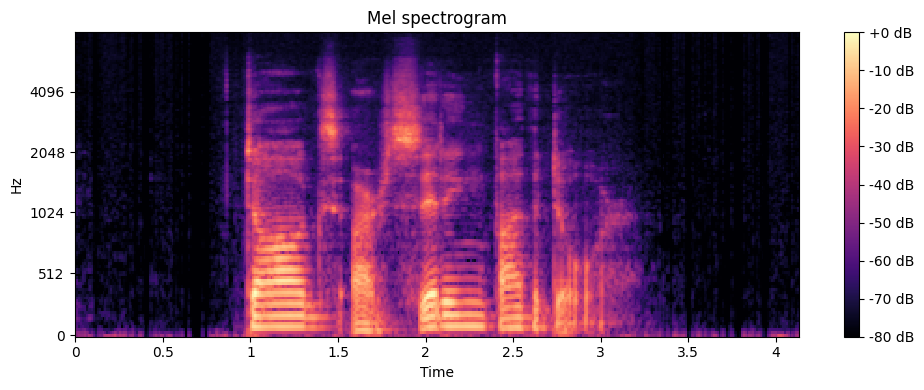

In [3]:
ravdess_path = os.path.join(os.getcwd(), "..", "data", "ravdess")
dataset = RAVDESSDataset(ravdess_path)
audio_data = dataset.load_audio(5)

# Assuming we want to display the first audio file
y, sr = audio_data[6]
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db, x_axis="time", y_axis="mel", sr=sr, fmax=8000)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel spectrogram")
plt.tight_layout()
plt.show()